<a href="https://colab.research.google.com/github/eshhha/ADULT_INCOME___PREDICTION/blob/plotting_dl/Adult_Income_prediction(preprocessing).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Esha

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#LIBRARIES

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import StandardScaler # StandardScaler is used for scaling numerical features


import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier        # KNN model
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier   # Gradient Boosting, AdaBoost
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import KFold,cross_val_score,RandomizedSearchCV
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV

from sklearn.ensemble import StackingClassifier     #stacking ensemble

#ANN model building
# Install tensorflow if it's not already installed
try:
    import tensorflow as tf
except ImportError:
    !pip install tensorflow
    import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

#READ DATASET

In [3]:
filepath = '/content/drive/MyDrive/AI ML Course/Data/adult.csv'
df_adult = pd.read_csv(filepath)
df_adult

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


#EDA(Exploratory Data Analysis)

In [4]:
# Check the number of rows and columns in the dataset
df_adult.shape

(48842, 15)

In [5]:
# Display summary statistics of the numerical columns
df_adult.describe()

,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,4.884200e+04,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,1.896641e+05,10.078089,1079.067626,87.502314,40.422382
std,13.710510,1.056040e+05,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.175505e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.781445e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.376420e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.490400e+06,16.000000,99999.000000,4356.000000,99.000000


In [6]:
# Display information about the DataFrame
df_adult.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              48842 non-null  int64 
 1   workclass        48842 non-null  object
 2   fnlwgt           48842 non-null  int64 
 3   education        48842 non-null  object
 4   educational-num  48842 non-null  int64 
 5   marital-status   48842 non-null  object
 6   occupation       48842 non-null  object
 7   relationship     48842 non-null  object
 8   race             48842 non-null  object
 9   gender           48842 non-null  object
 10  capital-gain     48842 non-null  int64 
 11  capital-loss     48842 non-null  int64 
 12  hours-per-week   48842 non-null  int64 
 13  native-country   48842 non-null  object
 14  income           48842 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.6+ MB


In [7]:
# Count the occurrences of each unique row in the DataFrame
df_adult.value_counts()

age  workclass  fnlwgt  education     educational-num  marital-status      occupation         relationship   race   gender  capital-gain  capital-loss  hours-per-week  native-country  income
25   Private    308144  Bachelors     13               Never-married       Craft-repair       Not-in-family  White  Male    0             0             40              Mexico          <=50K     3
                195994  1st-4th       2                Never-married       Priv-house-serv    Not-in-family  White  Female  0             0             40              Guatemala       <=50K     3
21   Private    243368  Preschool     1                Never-married       Farming-fishing    Not-in-family  White  Male    0             0             50              Mexico          <=50K     3
39   Private    184659  HS-grad       9                Married-civ-spouse  Machine-op-inspct  Husband        White  Male    0             0             40              United-States   <=50K     2
45   Private    82797   Bachelors     13               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             45              United-States   >50K      2
                                                                                                                                                                                                 ..
31   Private    156464  10th          6                Divorced            Other-service      Not-in-family  White  Male    0             0             40              United-States   <=50K     1
                        Bachelors     13               Never-married       Prof-specialty     Own-child      White  Male    0             0             25              United-States   <=50K     1
                156493  HS-grad       9                Never-married       Prof-specialty     Own-child      White  Male    0             0             40              United-States   <=50K     1
                        Some-college  10               Married-civ-spouse  Exec-managerial    Husband        White  Male    0             0             40              United-States   >50K      1
                152940  Some-college  10               Married-civ-spouse  Craft-repair       Husband        White  Male    0             0             40              United-States   <=50K     1
Name: count, Length: 48790, dtype: int64

In [8]:
# Count the total number of duplicate rows in the DataFrame
df_adult.duplicated().sum()

np.int64(52)

In [9]:
# Count the number of missing values in each column
df_adult.isna().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
educational-num,0
marital-status,0
occupation,0
relationship,0
race,0
gender,0


##PLOTS

In [10]:
# collecting numerical columns
num_cols = []
# collecting categorical columns
cat_cols = []

In [11]:
# Select the names of all numerical columns (integer and float data types)
num_cols = df_adult.select_dtypes(include=['int','float']).columns
# Select the names of all categorical columns (object and boolean data types)
cat_cols = df_adult.select_dtypes(include=['object','bool']).columns

In [12]:
# Display the names of the numerical columns
num_cols

Index(['age', 'fnlwgt', 'educational-num', 'capital-gain', 'capital-loss',
       'hours-per-week'],
      dtype='object')

In [13]:
# Display the names of the categorical columns
cat_cols

Index(['workclass', 'education', 'marital-status', 'occupation',
       'relationship', 'race', 'gender', 'native-country', 'income'],
      dtype='object')

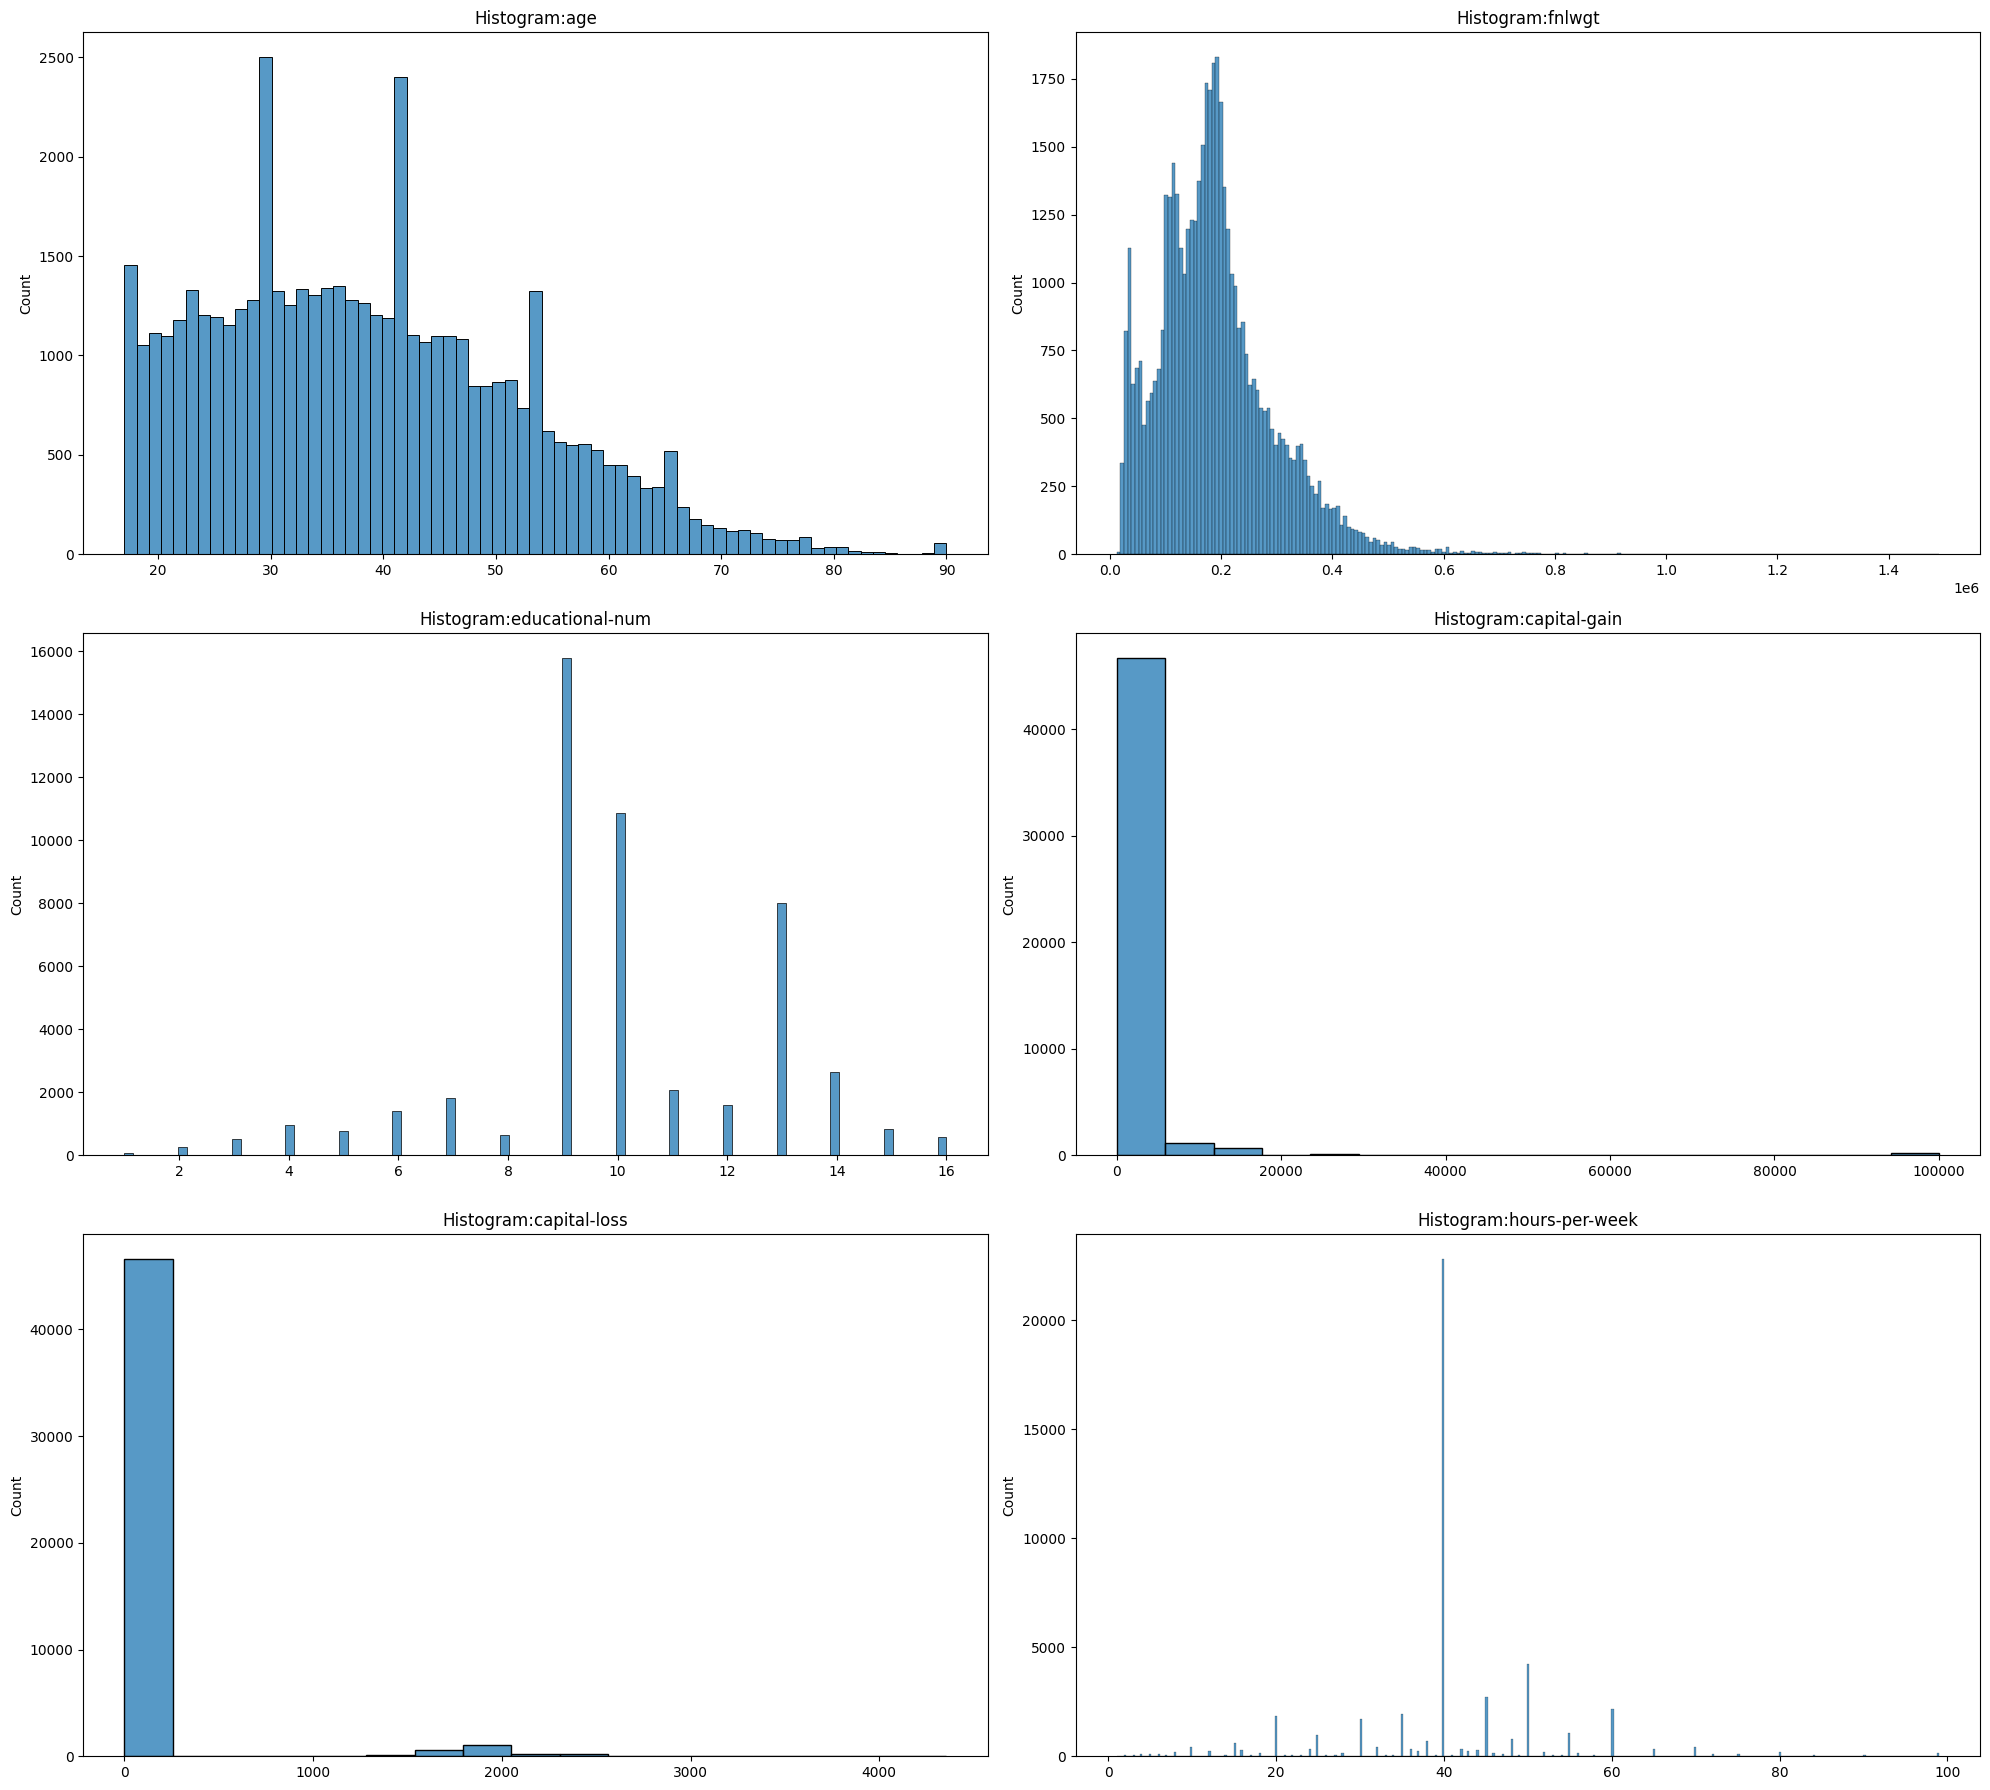

In [14]:
# Create histograms for each numerical column to understand the distribution of values
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.histplot(df_adult[col])
  plt.title(f'Histogram:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

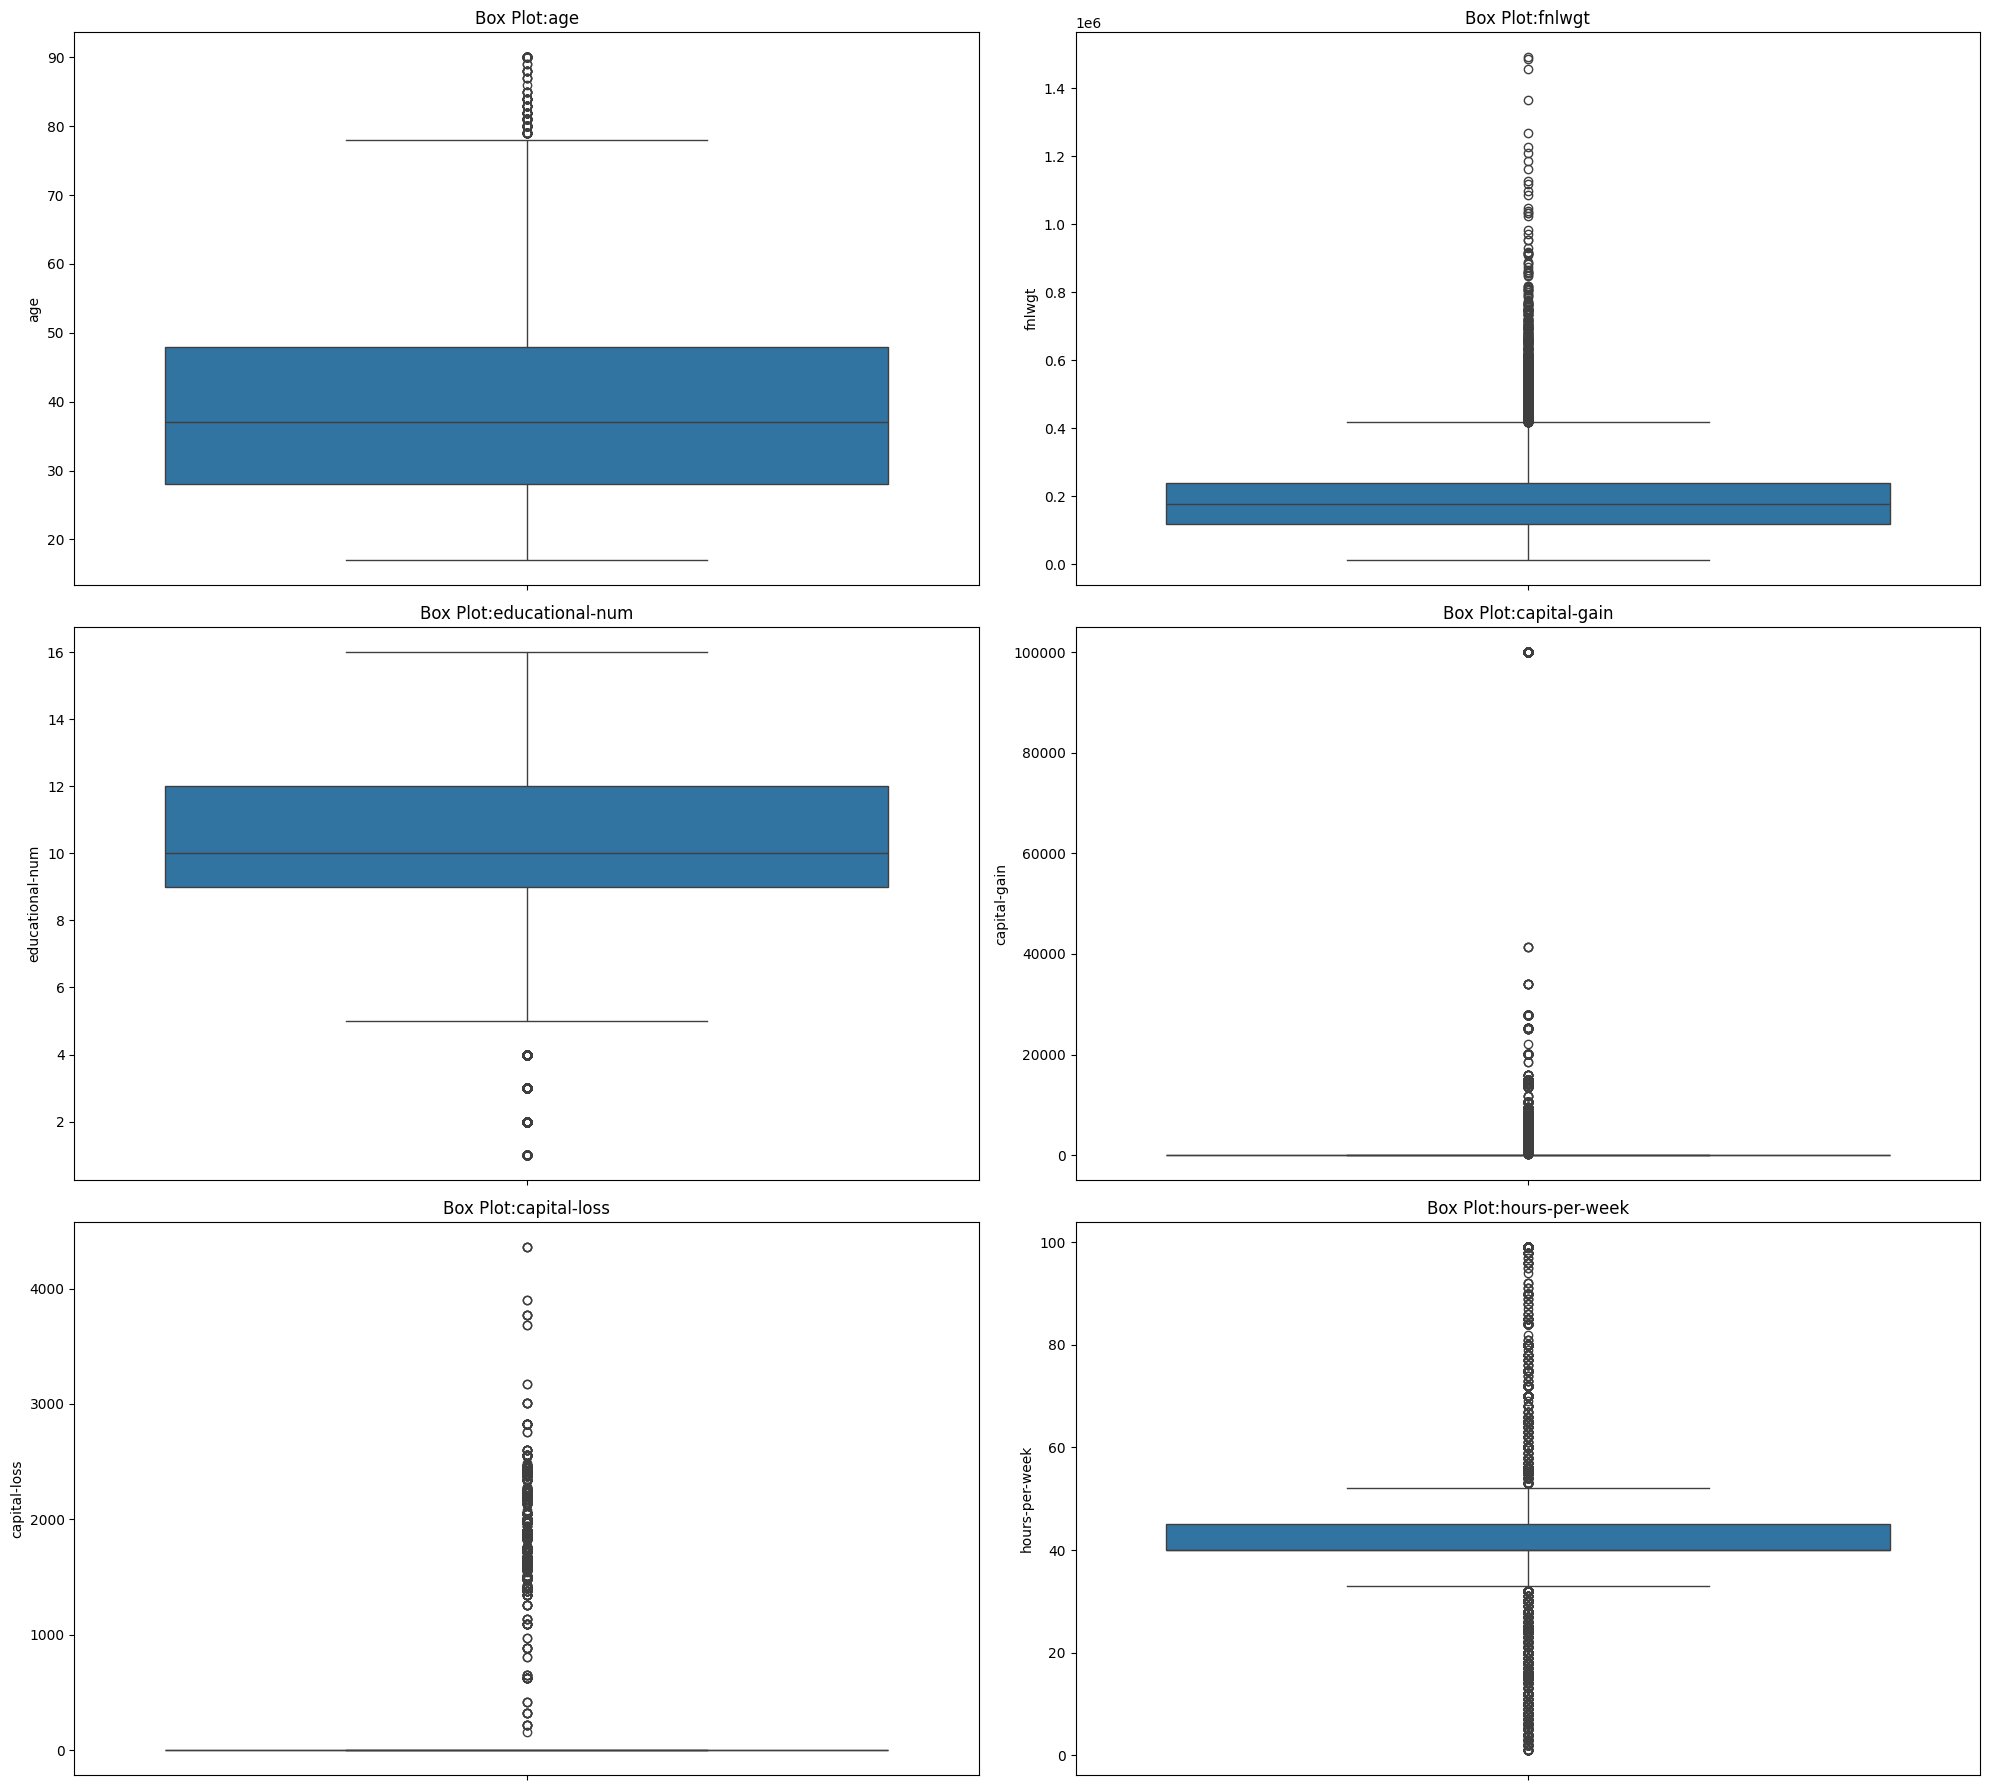

In [15]:
# Create box plots for all numerical features to detect potential outliers
plt.figure(figsize=(20,18))

for i,col in enumerate(num_cols):
  plt.subplot(3,2,i+1)
  sns.boxplot(df_adult[col])
  plt.title(f'Box Plot:{col}')
  plt.xlabel('')

plt.tight_layout()
plt.show()

###Correlation Matrix

In [16]:
#Identify relationships between numerical features.
corr_matrix = df_adult[num_cols].corr()
corr_matrix


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week
age,1.000000,-0.076628,0.030940,0.077229,0.056944,0.071558
fnlwgt,-0.076628,1.000000,-0.038761,-0.003706,-0.004366,-0.013519
educational-num,0.030940,-0.038761,1.000000,0.125146,0.080972,0.143689
capital-gain,0.077229,-0.003706,0.125146,1.000000,-0.031441,0.082157
capital-loss,0.056944,-0.004366,0.080972,-0.031441,1.000000,0.054467
hours-per-week,0.071558,-0.013519,0.143689,0.082157,0.054467,1.000000


Text(0.5, 1.0, 'Correlation heatmap')

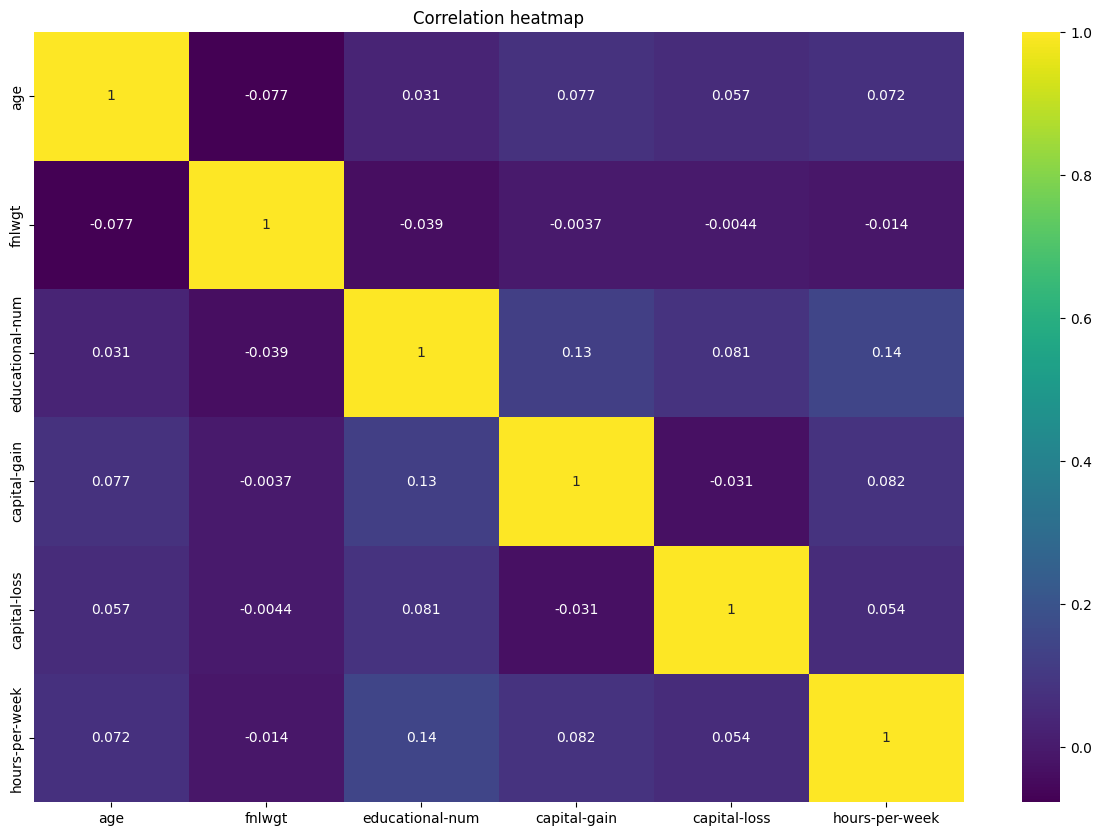

In [17]:
plt.figure(figsize =(15,10))
sns.heatmap(corr_matrix,annot = True,cmap = 'viridis',fmt = '.2g')
plt.title('Correlation heatmap')

#PREPROCESSING

###Muhammed Naif

##Data Cleaning

In [18]:
# Observation from EDA:
# df_adult.isna().sum()` showed 0 missing values.

# Hypothesis:
# The dataset may use "?" strings to represent missing values
# instead of standard NaN, causing pandas to miss them.

# Approach:
# 1. Verify if "?" exists in the data
# 2. If yes, convert them to NaN
# 3. Analyze the missing pattern
# 4. Decide filling strategy
# 5. Apply and verify

##Missing Value Handling

In [19]:
for column in df_adult.columns:
    # Only check object (text) columns
    if df_adult[column].dtype == 'object':
        # Count "?" occurrences
        question_count = (df_adult[column] == '?').sum()

        # Only print if "?" found
        if question_count > 0:
            print(f"{column}: {question_count} '?' values found")

workclass: 2799 '?' values found
occupation: 2809 '?' values found
native-country: 857 '?' values found


In [20]:
# Now that we confirmed "?" exists, replace them with NaN
# This allows pandas to detect them as proper missing values

# Replace all "?" values with NaN across entire DataFrame
df_adult = df_adult.replace('?', np.nan)

In [21]:
# --- Verify conversion worked ---
# Check missing values using standard method now

# Get counts of missing values
missing_counts = df_adult.isna().sum()

In [22]:
# Show only columns WITH missing values
missing_counts = missing_counts[missing_counts > 0]
print(missing_counts)

workclass         2799
occupation        2809
native-country     857
dtype: int64


In [23]:
# Calculate percentage

missing_percent = (missing_counts / len(df_adult)) * 100
print(missing_percent.round(2))

workclass         5.73
occupation        5.75
native-country    1.75
dtype: float64


In [24]:
# Show mode values for context
for col in ['workclass', 'occupation', 'native-country']:
    mode_val = df_adult[col].mode()[0]
    mode_count = (df_adult[col] == mode_val).sum()
    mode_pct = (mode_count / df_adult[col].notna().sum()) * 100

    print(f"{col}:")
    print(f"  Mode value: '{mode_val}'")
    print(f"  Represents: {mode_pct:.1f}% of non-missing data")
    print()

workclass:
  Mode value: 'Private'
  Represents: 73.6% of non-missing data

occupation:
  Mode value: 'Prof-specialty'
  Represents: 13.4% of non-missing data

native-country:
  Mode value: 'United-States'
  Represents: 91.3% of non-missing data



I am using a data-driven decision. When the mode represents a strong majority (over 70%), using mode is safe as it reflects the true dominant category. However, for occupation, the mode 'Prof-specialty' only represents 13.4% of data. Filling 2,809 missing values with it would artificially inflate this category, distorting the distribution. Instead, I used 'Unknown' to preserve the information that data was missing without biasing the model.

In [25]:
# Fill workclass with mode
workclass_mode = df_adult['workclass'].mode()[0]
df_adult['workclass'].fillna(workclass_mode, inplace=True)
print(f"✅ workclass filled with mode: '{workclass_mode}'")

✅ workclass filled with mode: 'Private'


In [26]:
# ill occupation with "Unknown"
df_adult['occupation'].fillna('Unknown', inplace=True)
print(f"✅ occupation filled with 'Unknown'")

✅ occupation filled with 'Unknown'


In [27]:
# Fill native-country with mode
country_mode = df_adult['native-country'].mode()[0]
df_adult['native-country'].fillna(country_mode, inplace=True)
print(f"✅ native-country filled with mode: '{country_mode}'")

✅ native-country filled with mode: 'United-States'


In [28]:
# Final Verification
total_missing = df_adult.isna().sum().sum()
print(f"Total missing values remaining: {total_missing}")

Total missing values remaining: 0


##Duplication Removal

In [29]:
current_duplicates = df_adult.duplicated().sum()
current_rows = df_adult.shape[0]

print(f"Current rows: {current_rows}")
print(f"Duplicate rows: {current_duplicates}")
print(f"Unique rows: {current_rows - current_duplicates}")

Current rows: 48842
Duplicate rows: 52
Unique rows: 48790


In [30]:
# --- Remove Duplicate Rows ---
# Strategy: keep='first' → keeps first occurrence, removes others
# Reason: Duplicates add bias; only 52 rows (0.1% loss) is acceptable

In [31]:
# Show before state
print(f"Rows BEFORE removal: {df_adult.shape[0]}")

Rows BEFORE removal: 48842


In [32]:
# Remove duplicates
df_adult = df_adult.drop_duplicates(keep='first')

In [33]:
# Show after state
print(f"Rows AFTER removal: {df_adult.shape[0]}")
print(f"Duplicates removed: {52}")

Rows AFTER removal: 48790
Duplicates removed: 52


In [34]:
# Verify no duplicates remain
remaining_duplicates = df_adult.duplicated().sum()
print(f"\nRemaining duplicates: {remaining_duplicates}")


Remaining duplicates: 0


###Outlier Handling

In [35]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    count = len(outliers)
    percentage = (count / len(df)) * 100

    return count, lower_bound, upper_bound, percentage

In [36]:
# --- Numerical columns to check ---
numerical_cols = ['age', 'fnlwgt', 'educational-num',
                  'capital-gain', 'capital-loss', 'hours-per-week']

In [37]:
# --- Detect outliers in each column ---
print("--- Outlier Detection Report ---\n")
print(f"{'Column':<20} {'Outliers':<10} {'% of Data':<12} {'Lower':<15} {'Upper':<15}")
print("-" * 72)

for col in numerical_cols:
    count, lower, upper, pct = detect_outliers_iqr(df_adult, col)
    print(f"{col:<20} {count:<10} {pct:<12.2f} {lower:<15.2f} {upper:<15.2f}")

--- Outlier Detection Report ---

Column               Outliers   % of Data    Lower           Upper          
------------------------------------------------------------------------
age                  215        0.44         -2.00           78.00          
fnlwgt               1453       2.98         -62521.88       417683.12      
educational-num      1787       3.66         4.50            16.50          
capital-gain         4035       8.27         0.00            0.00           
capital-loss         2282       4.68         0.00            0.00           
hours-per-week       13486      27.64        32.50           52.50          


In [38]:
# Outlier Handling: Cap Using IQR Method
# Strategy: Cap outliers in columns where IQR gives valid bounds
# Skip: capital-gain and capital-loss (zero-inflated, IQR returns 0-0)

In [39]:
# Columns where capping makes sense
cap_columns = ['age', 'fnlwgt', 'educational-num', 'hours-per-week']

In [40]:
# Loop through each column and cap outliers
for col in cap_columns:
    # Calculate IQR bounds
    Q1 = df_adult[col].quantile(0.25)
    Q3 = df_adult[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values above upper bound
    df_adult[col] = np.where(df_adult[col] > upper_bound, upper_bound, df_adult[col])

    # Cap values below lower bound (if applicable)
    df_adult[col] = np.where(df_adult[col] < lower_bound, lower_bound, df_adult[col])

    print(f"✅ {col}: Capped at [{lower_bound:.2f}, {upper_bound:.2f}]")

✅ age: Capped at [-2.00, 78.00]
✅ fnlwgt: Capped at [-62521.88, 417683.12]
✅ educational-num: Capped at [4.50, 16.50]
✅ hours-per-week: Capped at [32.50, 52.50]


In [41]:
# Capital-gain and capital-loss were skipped because 75% of
# values are 0, causing IQR to return invalid 0-0 bounds.

In [42]:
print("--- Final Dataset Status ---\n")
print(f"Total rows: {df_adult.shape[0]}")
print(f"Total columns: {df_adult.shape[1]}")
print(f"Missing values: {df_adult.isna().sum().sum()}")
print(f"Duplicate rows: {df_adult.duplicated().sum()}")

print("\n--- Data Types ---")
print(df_adult.dtypes.value_counts())

print("\n✅ Dataset ready for transformations!")

--- Final Dataset Status ---

Total rows: 48790
Total columns: 15
Missing values: 0
Duplicate rows: 34

--- Data Types ---
object     9
float64    4
int64      2
Name: count, dtype: int64

✅ Dataset ready for transformations!


In [43]:
# --- Save cleaned dataset for team members ---
# This file will be used for encoding, scaling, and modeling

df_adult.to_csv('adult_cleaned.csv', index=False)
print("✅ Cleaned dataset saved as 'adult_cleaned.csv'")
print("   Ready for team member to continue with transformations!")

✅ Cleaned dataset saved as 'adult_cleaned.csv'
   Ready for team member to continue with transformations!


#TRANSFORMATIONS

##Encoding

### Tojo

###Removing Independent Columns

In [44]:
df_adult.drop(columns=['race','educational-num','native-country'],inplace=True)

In [45]:
df_adult['income'].unique() # taking unique items in each column

array(['<=50K', '>50K'], dtype=object)

In [46]:
df_adult['gender'].unique() # taking unique items in each column

array(['Male', 'Female'], dtype=object)

In [47]:
# Label Encoding is used for binary categorical columns
# 'income' has only two categories
# 'gender' also has only two categories

In [48]:
label_enc = LabelEncoder()

df_adult['income'] = label_enc.fit_transform(df_adult['income'])
df_adult['gender'] = label_enc.fit_transform(df_adult['gender'])

In [49]:
df_adult.head(3) # label encoding done

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income
0,25.0,Private,226802.0,11th,Never-married,Machine-op-inspct,Own-child,1,0,0,40.0,0
1,38.0,Private,89814.0,HS-grad,Married-civ-spouse,Farming-fishing,Husband,1,0,0,50.0,0
2,28.0,Local-gov,336951.0,Assoc-acdm,Married-civ-spouse,Protective-serv,Husband,1,0,0,40.0,1


In [50]:
df_adult['education'].unique()  # taking unique items in each column

array(['11th', 'HS-grad', 'Assoc-acdm', 'Some-college', '10th',
       'Prof-school', '7th-8th', 'Bachelors', 'Masters', 'Doctorate',
       '5th-6th', 'Assoc-voc', '9th', '12th', '1st-4th', 'Preschool'],
      dtype=object)

In [51]:
# Ordinal Encoding is used because education categories

In [52]:
# OrdinalEncoder with the specified category order
edu_order = [['Preschool', '1st-4th', '5th-6th', '7th-8th', '9th', '10th', '11th', '12th', 'HS-grad', 'Some-college', 'Assoc-voc', 'Assoc-acdm',
                    'Bachelors', 'Masters', 'Prof-school', 'Doctorate']]

ordinal_encoder = OrdinalEncoder(categories=edu_order)

# Apply Ordinal Encoding to the education column
df_adult[['education']] = ordinal_encoder.fit_transform(df_adult[['education']])

In [53]:
df_adult.head(3) # after ordinal encoding

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income
0,25.0,Private,226802.0,6.0,Never-married,Machine-op-inspct,Own-child,1,0,0,40.0,0
1,38.0,Private,89814.0,8.0,Married-civ-spouse,Farming-fishing,Husband,1,0,0,50.0,0
2,28.0,Local-gov,336951.0,11.0,Married-civ-spouse,Protective-serv,Husband,1,0,0,40.0,1


In [54]:
df_adult['workclass'].unique()  # taking unique items in each column

array(['Private', 'Local-gov', 'Self-emp-not-inc', 'Federal-gov',
       'State-gov', 'Self-emp-inc', 'Without-pay', 'Never-worked'],
      dtype=object)

In [55]:
# the order for workclass categories
workclass_order = [['Never-worked', 'Without-pay', 'Private', 'Self-emp-not-inc', 'Self-emp-inc', 'Local-gov', 'State-gov','Federal-gov']]

# Create the OrdinalEncoder with the specified category order
ordinal_encoder = OrdinalEncoder(categories=workclass_order)

# Apply Ordinal Encoding to the workclass column
df_adult[['workclass']] = ordinal_encoder.fit_transform(df_adult[['workclass']])

In [56]:
df_adult.head(3) # after ordinal encoding

,age,workclass,fnlwgt,education,marital-status,occupation,relationship,gender,capital-gain,capital-loss,hours-per-week,income
0,25.0,2.0,226802.0,6.0,Never-married,Machine-op-inspct,Own-child,1,0,0,40.0,0
1,38.0,2.0,89814.0,8.0,Married-civ-spouse,Farming-fishing,Husband,1,0,0,50.0,0
2,28.0,5.0,336951.0,11.0,Married-civ-spouse,Protective-serv,Husband,1,0,0,40.0,1


In [57]:
df_adult['marital-status'].unique()  # taking unique items in each column

array(['Never-married', 'Married-civ-spouse', 'Widowed', 'Divorced',
       'Separated', 'Married-spouse-absent', 'Married-AF-spouse'],
      dtype=object)

In [58]:
df_adult['occupation'].unique() # taking unique items in each column

array(['Machine-op-inspct', 'Farming-fishing', 'Protective-serv',
       'Unknown', 'Other-service', 'Prof-specialty', 'Craft-repair',
       'Adm-clerical', 'Exec-managerial', 'Tech-support', 'Sales',
       'Priv-house-serv', 'Transport-moving', 'Handlers-cleaners',
       'Armed-Forces'], dtype=object)

In [59]:
df_adult['relationship'].unique() # taking unique items in each column

array(['Own-child', 'Husband', 'Not-in-family', 'Unmarried', 'Wife',
       'Other-relative'], dtype=object)

In [60]:
# these columns are not having proper order so used the one hot encoding method
one_hot_cols = ['marital-status', 'occupation', 'relationship']
df_ohc = pd.get_dummies(
    df_adult,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int
)

In [61]:
df_ohc.head(3) # after onehot encoding

,age,workclass,fnlwgt,education,gender,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,25.0,2.0,226802.0,6.0,1,0,0,40.0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,38.0,2.0,89814.0,8.0,1,0,0,50.0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,28.0,5.0,336951.0,11.0,1,0,0,40.0,1,0,...,1,0,0,0,0,0,0,0,0,0


In [62]:
print("Before encoding:", df_adult.shape)
print("After encoding:", df_ohc.shape)

Before encoding: (48790, 12)
After encoding: (48790, 34)


In [63]:
# After One-Hot Encoding, the number of columns increased from 15 to 85

In [64]:
df_ohc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48790 entries, 0 to 48841
Data columns (total 34 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   48790 non-null  float64
 1   workclass                             48790 non-null  float64
 2   fnlwgt                                48790 non-null  float64
 3   education                             48790 non-null  float64
 4   gender                                48790 non-null  int64  
 5   capital-gain                          48790 non-null  int64  
 6   capital-loss                          48790 non-null  int64  
 7   hours-per-week                        48790 non-null  float64
 8   income                                48790 non-null  int64  
 9   marital-status_Married-AF-spouse      48790 non-null  int64  
 10  marital-status_Married-civ-spouse     48790 non-null  int64  
 11  marital-status_Marri

#Data Splitting

In [65]:
# Data Splitting

y = df_ohc['income']
X = df_ohc.drop('income',axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,    # training 80% and testing 20%
    random_state=42     # used to get same random states fot testing
)

#Scaling

In [66]:
# Display all column names
df_ohc.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'gender', 'capital-gain',
       'capital-loss', 'hours-per-week', 'income',
       'marital-status_Married-AF-spouse', 'marital-status_Married-civ-spouse',
       'marital-status_Married-spouse-absent', 'marital-status_Never-married',
       'marital-status_Separated', 'marital-status_Widowed',
       'occupation_Armed-Forces', 'occupation_Craft-repair',
       'occupation_Exec-managerial', 'occupation_Farming-fishing',
       'occupation_Handlers-cleaners', 'occupation_Machine-op-inspct',
       'occupation_Other-service', 'occupation_Priv-house-serv',
       'occupation_Prof-specialty', 'occupation_Protective-serv',
       'occupation_Sales', 'occupation_Tech-support',
       'occupation_Transport-moving', 'occupation_Unknown',
       'relationship_Not-in-family', 'relationship_Other-relative',
       'relationship_Own-child', 'relationship_Unmarried',
       'relationship_Wife'],
      dtype='object')

In [67]:
# These columns contain large numerical values and need scaling
scale_cols = ['age', 'fnlwgt', 'capital-gain', 'capital-loss',
              'hours-per-week']

In [68]:
# Create StandardScaler object
scaler = StandardScaler()

In [69]:
# Scale the selected columns
df_ohc[scale_cols] = scaler.fit_transform(df_ohc[scale_cols])

In [70]:
# Display first 3 rows
df_ohc.head(3)

,age,workclass,fnlwgt,education,gender,capital-gain,capital-loss,hours-per-week,income,marital-status_Married-AF-spouse,...,occupation_Protective-serv,occupation_Sales,occupation_Tech-support,occupation_Transport-moving,occupation_Unknown,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife
0,-0.999931,2.0,0.419962,6.0,1,-0.144882,-0.217248,-0.193066,0,0,...,0,0,0,0,0,0,0,1,0,0
1,-0.046078,2.0,-1.017118,8.0,1,-0.144882,-0.217248,1.423574,0,0,...,0,0,0,0,0,0,0,0,0,0
2,-0.779811,5.0,1.575485,11.0,1,-0.144882,-0.217248,-0.193066,1,0,...,1,0,0,0,0,0,0,0,0,0


In [71]:
# Check if scaling worked correctly
df_ohc[scale_cols].describe()

,age,fnlwgt,capital-gain,capital-loss,hours-per-week
count,4.879000e+04,4.879000e+04,4.879000e+04,4.879000e+04,4.879000e+04
mean,1.278657e-16,1.479630e-16,-3.029164e-17,-4.077720e-17,8.737972e-18
std,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00,1.000010e+00
min,-1.586917e+00,-1.830440e+00,-1.448823e-01,-2.172482e-01,-1.405545e+00
25%,-7.798110e-01,-7.260995e-01,-1.448823e-01,-2.172482e-01,-1.930657e-01
50%,-1.194515e-01,-9.054525e-02,-1.448823e-01,-2.172482e-01,-1.930657e-01
75%,6.876545e-01,5.333041e-01,-1.448823e-01,-2.172482e-01,6.152541e-01
max,2.888853e+00,2.422410e+00,1.326731e+01,1.058619e+01,1.827734e+00


In [72]:
print("Before scaling:")
print(df_adult[scale_cols].head())

print("\nAfter scaling:")
print(df_ohc[scale_cols].head())

Before scaling:
    age    fnlwgt  capital-gain  capital-loss  hours-per-week
0  25.0  226802.0             0             0            40.0
1  38.0   89814.0             0             0            50.0
2  28.0  336951.0             0             0            40.0
3  44.0  160323.0          7688             0            40.0
4  18.0  103497.0             0             0            32.5

After scaling:
        age    fnlwgt  capital-gain  capital-loss  hours-per-week
0 -0.999931  0.419962     -0.144882     -0.217248       -0.193066
1 -0.046078 -1.017118     -0.144882     -0.217248        1.423574
2 -0.779811  1.575485     -0.144882     -0.217248       -0.193066
3  0.394161 -0.277440      0.886257     -0.217248       -0.193066
4 -1.513544 -0.873576     -0.144882     -0.217248       -1.405545


In [73]:
print("Shape after scaling:", df_ohc.shape)

Shape after scaling: (48790, 34)


In [74]:
# Scaling is performed to bring all numerical columns to the same range

# Columns with very large values can dominate ML models

# StandardScaler converts data using:
# z = (x - mean) / standard deviation

# After scaling:
# Mean becomes approximately 0
# Standard deviation becomes approximately 1

#Model Building

## Muhammed Naif

In [75]:
# MODELS: KNN + Gradient Boosting
# TASK: Base Model + Ensemble + Cross Validation + Hyperparameter Tuning

In [76]:
from sklearn.model_selection import (
    cross_val_score,    # Cross validation scoring
    GridSearchCV,       # Hyperparameter tuning
    StratifiedKFold     # Stratified K-Fold strategy
)

In [77]:
from sklearn.metrics import (
    accuracy_score,          # Overall accuracy
    classification_report,   # Precision, Recall, F1
    confusion_matrix,        # Confusion matrix
    ConfusionMatrixDisplay,  # Confusion matrix visualization
    roc_auc_score,           # ROC AUC Score
    roc_curve                # ROC Curve plotting
)

##Issue Identified: Data Leakage + Incorrect Scaling

During preprocessing, two issues were identified:

**Issue 1 — Data Leakage:**
Scaling was applied to the full dataset (df_ohc) instead of
fitting on X_train only and transforming X_test separately.

**Issue 2 — X_train and X_test Unscaled:**
Train Test Split was done BEFORE scaling.
This means X_train and X_test contain unscaled values.
Scaling df_ohc after the split does NOT update X_train and X_test.

**Fix Applied:**
- Recreate X_train and X_test from df_ohc
- Fit scaler ONLY on X_train
- Transform X_test using the SAME scaler
- This ensures no data leakage and correct scaling

In [78]:
y = df_ohc['income']

X = df_ohc.drop('income', axis=1)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (48790, 33)
y shape: (48790,)


In [79]:
# --- Step 2: Train Test Split ---

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X,                  # Feature variables
    y,                  # Target variable
    test_size=0.2,      # 80% train, 20% test
    random_state=42,    # Reproducibility
    stratify=y          # Maintain class balance
)

In [81]:
# Check class balance in train and test
print("\nClass balance in y_train:")
print(y_train.value_counts(normalize=True).round(2))

print("\nClass balance in y_test:")
print(y_test.value_counts(normalize=True).round(2))


Class balance in y_train:
income
0    0.76
1    0.24
Name: proportion, dtype: float64

Class balance in y_test:
income
0    0.76
1    0.24
Name: proportion, dtype: float64


In [82]:
# BLOCK 4: Correct Scaling — Fix Data Leakage

In [83]:
# Columns that need scaling
# Only numerical columns with large value ranges
scale_cols = ['age', 'fnlwgt', 'capital-gain',
              'capital-loss', 'hours-per-week']

In [84]:
scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [85]:
# Verify scaling worked on X_train
print("\nX_train after scaling:")
print(X_train[scale_cols].describe().round(2))

# Verify scaling worked on X_test
print("\nX_test after scaling:")
print(X_test[scale_cols].describe().round(2))


X_train after scaling:
            age    fnlwgt  capital-gain  capital-loss  hours-per-week
count  39032.00  39032.00      39032.00      39032.00        39032.00
mean       0.00      0.00          0.00          0.00           -0.00
std        1.00      1.00          1.00          1.00            1.00
min       -1.59     -1.83         -0.14         -0.22           -1.40
25%       -0.78     -0.72         -0.14         -0.22           -0.19
50%       -0.12     -0.09         -0.14         -0.22           -0.19
75%        0.69      0.53         -0.14         -0.22            0.62
max        2.89      2.42         13.09         10.51            1.83

X_test after scaling:
           age   fnlwgt  capital-gain  capital-loss  hours-per-week
count  9758.00  9758.00       9758.00       9758.00         9758.00
mean      0.00    -0.00         -0.01         -0.02            0.01
std       1.00     1.00          0.93          0.97            1.00
min      -1.59    -1.82         -0.14         -0.22

##KNN

In [86]:
knn_base = KNeighborsClassifier(n_neighbors=5)

knn_base.fit(X_train, y_train)

y_pred_knn = knn_base.predict(X_test)

print(f"\nFirst 10 predictions : {y_pred_knn[:10]}")
print(f"First 10 actual values: {y_test.values[:10]}")


First 10 predictions : [0 1 0 0 0 0 0 0 0 0]
First 10 actual values: [0 0 0 0 1 0 0 0 0 0]


### KNN Base Model Evaluation

Accuracy  : 0.8290
ROC AUC   : 0.8555

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.90      0.89      7422
        >50K       0.65      0.62      0.63      2336

    accuracy                           0.83      9758
   macro avg       0.77      0.76      0.76      9758
weighted avg       0.83      0.83      0.83      9758



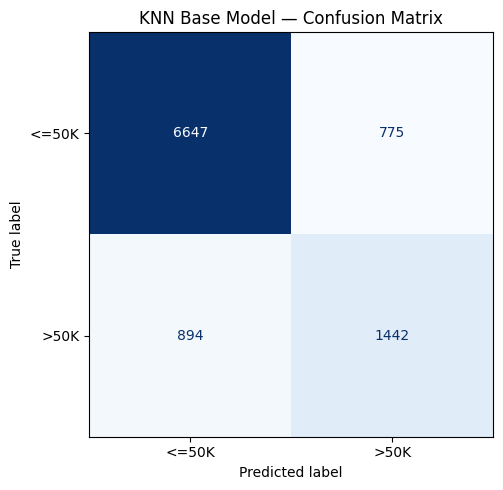

In [87]:
# Accuracy Score
# Overall percentage of correct predictions
knn_accuracy = accuracy_score(y_test, y_pred_knn)

# ROC AUC Score
knn_roc_auc = roc_auc_score(
    y_test,
    knn_base.predict_proba(X_test)[:, 1]  # Probability of class 1
)

# Classification Report
# Shows Precision, Recall, F1 for each class
print(f"Accuracy  : {knn_accuracy:.4f}")
print(f"ROC AUC   : {knn_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn,
      target_names=['<=50K', '>50K']))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=['<=50K', '>50K']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
plt.title("KNN Base Model — Confusion Matrix")
plt.tight_layout()
plt.show()

###KNN Cross Validation

In [88]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [89]:
cv_scores_knn = cross_val_score(
    knn_base,       # Model to evaluate
    X_train,        # Training features only
    y_train,        # Training labels only
    cv=skf,         # Cross validation strategy
    scoring='accuracy',  # Metric to evaluate
    n_jobs=-1       # Use all CPU cores for speed
)

In [90]:
print(f"Individual Fold Scores : {cv_scores_knn.round(4)}")
print(f"Mean CV Score          : {cv_scores_knn.mean():.4f}")
print(f"Standard Deviation     : {cv_scores_knn.std():.4f}")
print(f"Min Score              : {cv_scores_knn.min():.4f}")
print(f"Max Score              : {cv_scores_knn.max():.4f}")

print("\nMeaning:")
print(f"KNN performs with {cv_scores_knn.mean()*100:.2f}% accuracy on average")
print(f"Variation of ±{cv_scores_knn.std()*100:.2f}% across all folds")


Individual Fold Scores : [0.8355 0.8332 0.8322 0.8324 0.8353]
Mean CV Score          : 0.8337
Standard Deviation     : 0.0014
Min Score              : 0.8322
Max Score              : 0.8355

Meaning:
KNN performs with 83.37% accuracy on average
Variation of ±0.14% across all folds


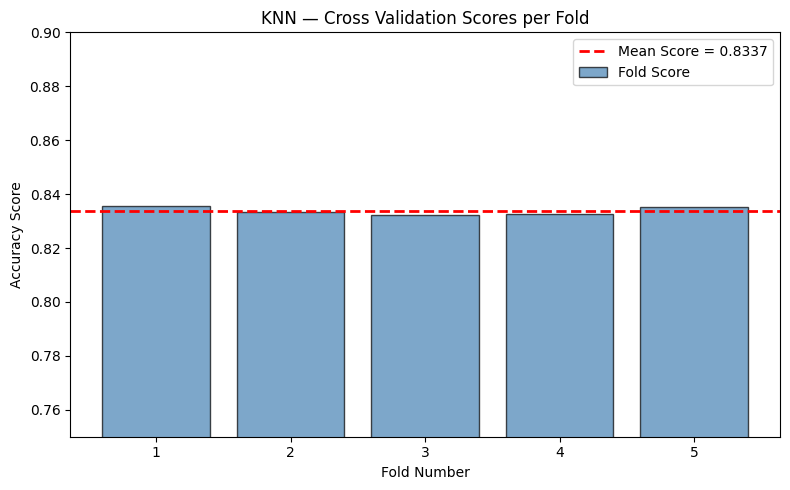

In [91]:
# Visualize CV Scores
plt.figure(figsize=(8, 5))

plt.bar(
    range(1, 6),
    cv_scores_knn,
    color='steelblue',
    edgecolor='black',
    alpha=0.7,
    label='Fold Score'
)

plt.axhline(
    y=cv_scores_knn.mean(),
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean Score = {cv_scores_knn.mean():.4f}'
)

plt.xlabel('Fold Number')
plt.ylabel('Accuracy Score')
plt.title('KNN — Cross Validation Scores per Fold')
plt.xticks(range(1, 6))
plt.ylim([0.75, 0.90])
plt.legend()
plt.tight_layout()
plt.show()

### KNN Hyperparameter Tuning

In [92]:
# All hyperparameter combinations to try
param_grid_knn = {
    'n_neighbors': [3, 5, 7, 9, 11, 15, 20],  # K values
    'weights'    : ['uniform', 'distance'],      # Weight strategy
    'metric'     : ['euclidean', 'manhattan']    # Distance metric
}

In [93]:
# Step 2: Create Grid Search Object

grid_search_knn = GridSearchCV(
    estimator=KNeighborsClassifier(),  # Base model
    param_grid=param_grid_knn,         # Parameters to try
    cv=skf,                            # Same CV strategy as before
    scoring='accuracy',                # Metric to optimize
    n_jobs=-1,                         # Use all CPU cores
    verbose=1                          # Show progress
)


In [94]:
# Fit Grid Search
# This will try all 28 combinations with 5-fold CV
print(" Starting— this may take a while ")
grid_search_knn.fit(X_train, y_train)

 Starting— this may take a while 
Fitting 5 folds for each of 28 candidates, totalling 140 fits


KeyboardInterrupt: 

In [ ]:
# Display Best Parameters
print(f"Best Parameters : {grid_search_knn.best_params_}")
print(f"Best CV Score   : {grid_search_knn.best_score_:.4f}")

print("\nMeaning:")
print(f"The best K value found is: {grid_search_knn.best_params_['n_neighbors']}")
print(f"The best weight strategy is: {grid_search_knn.best_params_['weights']}")
print(f"The best distance metric is: {grid_search_knn.best_params_['metric']}")
print(f"With CV Accuracy: {grid_search_knn.best_score_*100:.2f}%")

### Evaluate Tuned KNN Model

In [95]:
# best_estimator_ is the model with best parameters
knn_tuned = grid_search_knn.best_estimator_

# Predict on Test Data
y_pred_knn_tuned = knn_tuned.predict(X_test)

# Calculate Metrics
knn_tuned_accuracy = accuracy_score(y_test, y_pred_knn_tuned)
knn_tuned_roc_auc = roc_auc_score(
    y_test,
    knn_tuned.predict_proba(X_test)[:, 1]
)

# Display Results
print(f"Best Parameters : {grid_search_knn.best_params_}")
print(f"Test Accuracy   : {knn_tuned_accuracy:.4f}")
print(f"Test ROC AUC    : {knn_tuned_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn_tuned,
      target_names=['<=50K', '>50K']))

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [ ]:
# Confusion Matrix
cm_knn_tuned = confusion_matrix(y_test, y_pred_knn_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn_tuned,
    display_labels=['<=50K', '>50K']
)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
plt.title("KNN Tuned Model — Confusion Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# Compare Base vs Tuned
print(f"{'Metric':<15} {'Base (K=5)':<15} {'Tuned (K=20)':<15} {'Improvement':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} {knn_accuracy:<15.4f} {knn_tuned_accuracy:<15.4f} {(knn_tuned_accuracy - knn_accuracy):+.4f}")
print(f"{'ROC AUC':<15} {knn_roc_auc:<15.4f} {knn_tuned_roc_auc:<15.4f} {(knn_tuned_roc_auc - knn_roc_auc):+.4f}")

## Gradient Boosting Base Model

In [96]:
gb_base = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# Train Model
print(" Training Gradient Boosting")
gb_base.fit(X_train, y_train)
print("Gradient Boosting Trained Successfully")


 Training Gradient Boosting
Gradient Boosting Trained Successfully


In [97]:
# Predict on Test Data
y_pred_gb = gb_base.predict(X_test)

# Calculate Metrics
gb_accuracy = accuracy_score(y_test, y_pred_gb)
gb_roc_auc = roc_auc_score(
    y_test,
    gb_base.predict_proba(X_test)[:, 1]
)

# Display Results
print(f"Test Accuracy : {gb_accuracy:.4f}")
print(f"Test ROC AUC  : {gb_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb,
      target_names=['<=50K', '>50K']))

Test Accuracy : 0.8633
Test ROC AUC  : 0.9182

Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91      7422
        >50K       0.78      0.60      0.68      2336

    accuracy                           0.86      9758
   macro avg       0.83      0.77      0.80      9758
weighted avg       0.86      0.86      0.86      9758



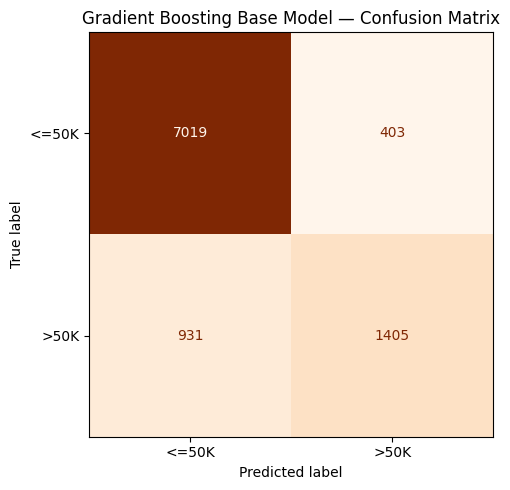

In [98]:
# Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb,
    display_labels=['<=50K', '>50K']
)
disp.plot(ax=ax, colorbar=False, cmap='Oranges')
plt.title("Gradient Boosting Base Model — Confusion Matrix")
plt.tight_layout()
plt.show()

### Gradient Boosting Hyperparameter Tuning (GridSearchCV)

In [ ]:
# Define Parameter Grid
param_grid_gb = {
    'n_estimators'  : [100, 200],
    'learning_rate' : [0.05, 0.1, 0.15],
    'max_depth'     : [3, 4, 5]
}

# Create Grid Search Object
grid_search_gb = GridSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_grid=param_grid_gb,
    cv=skf,                 # Same 5-fold stratified CV
    scoring='accuracy',
    n_jobs=-1,              # Use all CPU cores
    verbose=1
)

grid_search_gb.fit(X_train, y_train)

In [ ]:
print(f"Best Parameters : {grid_search_gb.best_params_}")
print(f"Best CV Score   : {grid_search_gb.best_score_:.4f}")

print("\nMeaning:")
for param, value in grid_search_gb.best_params_.items():
    print(f"Best {param}: {value}")
print(f"With CV Accuracy: {grid_search_gb.best_score_*100:.2f}%")

### Gradient Boosting Tuned Evaluation

In [100]:
# Get Best Model from Grid Search
gb_tuned = grid_search_gb.best_estimator_

# Predict on Test Data
y_pred_gb_tuned = gb_tuned.predict(X_test)

# Calculate Metrics
gb_tuned_accuracy = accuracy_score(y_test, y_pred_gb_tuned)
gb_tuned_roc_auc = roc_auc_score(
    y_test,
    gb_tuned.predict_proba(X_test)[:, 1]
)

# Display Results
print(f"Best Parameters : {grid_search_gb.best_params_}")
print(f"Test Accuracy   : {gb_tuned_accuracy:.4f}")
print(f"Test ROC AUC    : {gb_tuned_roc_auc:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb_tuned,
      target_names=['<=50K', '>50K']))

NameError: name 'grid_search_gb' is not defined

In [101]:
# --- Step 5: Confusion Matrix ---
cm_gb_tuned = confusion_matrix(y_test, y_pred_gb_tuned)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_gb_tuned,
    display_labels=['<=50K', '>50K']
)
disp.plot(ax=ax, colorbar=False, cmap='Purples')
plt.title("Gradient Boosting Tuned Model — Confusion Matrix")
plt.tight_layout()
plt.show()

NameError: name 'y_pred_gb_tuned' is not defined

In [102]:
print(f"{'Metric':<15} {'Base':<15} {'Tuned':<15} {'Improvement':<15}")
print("-" * 60)
print(f"{'Accuracy':<15} {gb_accuracy:<15.4f} {gb_tuned_accuracy:<15.4f} {(gb_tuned_accuracy - gb_accuracy):+.4f}")
print(f"{'ROC AUC':<15} {gb_roc_auc:<15.4f} {gb_tuned_roc_auc:<15.4f} {(gb_tuned_roc_auc - gb_roc_auc):+.4f}")

Metric          Base            Tuned           Improvement    
------------------------------------------------------------


NameError: name 'gb_tuned_accuracy' is not defined

## Final Model Comparison

In [103]:
# Create Results DataFrame
results = {
    'Model': [
        'KNN (Base)',
        'KNN (Tuned)',
        'Gradient Boosting (Base)',
        'Gradient Boosting (Tuned)'
    ],
    'Accuracy': [
        knn_accuracy,
        knn_tuned_accuracy,
        gb_accuracy,
        gb_tuned_accuracy
    ],
    'ROC AUC': [
        knn_roc_auc,
        knn_tuned_roc_auc,
        gb_roc_auc,
        gb_tuned_roc_auc
    ]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

NameError: name 'knn_tuned_accuracy' is not defined

In [104]:
# Find Best Model
best_model_idx = results_df['Accuracy'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_accuracy = results_df.loc[best_model_idx, 'Accuracy']
best_roc_auc = results_df.loc[best_model_idx, 'ROC AUC']

print(f"BEST MODEL: {best_model_name}")
print(f"Accuracy: {best_accuracy:.4f}")
print(f"ROC AUC : {best_roc_auc:.4f}")

NameError: name 'results_df' is not defined

In [ ]:
print(f"KNN Base       AUC = {knn_roc_auc:.4f}")
print(f"KNN Tuned      AUC = {knn_tuned_roc_auc:.4f}")
print(f"GB Base        AUC = {gb_roc_auc:.4f}")
print(f"GB Tuned       AUC = {gb_tuned_roc_auc:.4f}")

## Decision Tree

Aleena

In [105]:
#  Build Decision Tree Model

dt_model = DecisionTreeClassifier(
    criterion='gini',      # You can also use 'entropy'
    random_state=42
)

#Train the Model

dt_model.fit(X_train, y_train)


# Make Predictions

y_pred_DT = dt_model.predict(X_test)


In [106]:

#  Evaluate the Model

accuracy = accuracy_score(y_test, y_pred_DT)
precision = precision_score(y_test, y_pred_DT)
recall = recall_score(y_test, y_pred_DT)
f1 = f1_score(y_test, y_pred_DT)

print("Decision Tree Classification Results")
print("------------------------------------")
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))



Decision Tree Classification Results
------------------------------------
Accuracy : 0.8197
Precision: 0.6169
Recall   : 0.6515
F1 Score : 0.6338


In [107]:
#build the model object
dT_model = DecisionTreeClassifier()
#Train the model
dT_model.fit(X_train,y_train)
#make predictions using the model
y_pred_DT = dT_model.predict(X_test)
#evaluate the model
acc_DT = accuracy_score(y_test,y_pred_DT)

In [108]:
cm = confusion_matrix(y_test,y_pred_DT)
print(cm)

[[6457  965]
 [ 822 1514]]


In [109]:
print(classification_report(y_test,y_pred_DT))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88      7422
           1       0.61      0.65      0.63      2336

    accuracy                           0.82      9758
   macro avg       0.75      0.76      0.75      9758
weighted avg       0.82      0.82      0.82      9758



In [110]:
kf_obj = KFold(n_splits = 5, shuffle = True)

scores = cross_val_score(DecisionTreeClassifier(), X, y, cv = kf_obj)
print('Cross validation scores:',scores)
# print('Mean of cv scores:', np.mean(scores))
print('Mean of cv scores:', scores.mean())
print('Minimum cv:', scores.min())
print('Maximum cv:', scores.max())
diff = scores.max() - scores.min()
print('Difference b/w min and max cv:', diff)

Cross validation scores: [0.81779053 0.81235909 0.81082189 0.80856733 0.81963517]
Mean of cv scores: 0.8138348022135684
Minimum cv: 0.8085673293707727
Maximum cv: 0.8196351711416274
Difference b/w min and max cv: 0.011067841770854736


In [111]:
# Define the parameters you want to check
para_grid = {'criterion': ['gini','entropy'],
             'max_depth': [2,3,4,5,6],
              'min_samples_split': [2,4,6]}

# build the model obj
grid = GridSearchCV(DecisionTreeClassifier(), para_grid, cv = 5, scoring = 'accuracy')


# train the model
grid.fit(X_train, y_train)

print('Best parameters are: ', grid.best_params_)
print('Best cross validation score is: ', grid.best_score_)


# We build the model using the best parameters identified
dT_model_HPT = DecisionTreeClassifier(criterion = 'gini', max_depth = 3, min_samples_split = 2)

# Train the model
dT_model_HPT.fit(X_train, y_train)
# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)
# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)
print('Accuracy :', acc_dT_HPT)

KeyboardInterrupt: 

In [112]:
# Define the parameters to check
para_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 4, 6]
}

# Build the model object
random_search = RandomizedSearchCV(
    DecisionTreeClassifier(),
    param_distributions=para_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

# Display the best parameters and score
print('Best parameters are:', random_search.best_params_)
print('Best cross validation score is:', random_search.best_score_)

# Build the model using the best parameters
dT_model_HPT = random_search.best_estimator_

# Make predictions using the model
y_pred_dT_HPT = dT_model_HPT.predict(X_test)

# Evaluate the model performance
acc_dT_HPT = accuracy_score(y_test, y_pred_dT_HPT)

print('Accuracy:', acc_dT_HPT)

Best parameters are: {'min_samples_split': 2, 'max_depth': 6, 'criterion': 'gini'}
Best cross validation score is: 0.8557336631450237
Accuracy: 0.8502766960442714


##Bagging

In [113]:


# Bagging Classifier
bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=42),
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)



In [114]:
# Train the model
bagging_model.fit(X_train, y_train)

# Predict
y_pred_bag = bagging_model.predict(X_test)



In [115]:
# Evaluation
accuracy = accuracy_score(y_test, y_pred_bag)
precision = precision_score(y_test, y_pred_bag)
recall = recall_score(y_test, y_pred_bag)
f1 = f1_score(y_test, y_pred_bag)

print("Bagging Classifier Results")
print("--------------------------")
print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))



Bagging Classifier Results
--------------------------
Accuracy : 0.8554
Precision: 0.7268
Recall   : 0.6344
F1 Score : 0.6775


###Cross Validation

In [116]:

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    bagging_model,
    X_train,
    y_train,
    cv=skf,
    scoring="accuracy",
    n_jobs=-1
)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Score:", cv_scores.mean())
print("Minimum Score:", cv_scores.min())
print("Maximum Score:", cv_scores.max())
print("Standard Deviation:", cv_scores.std())

Cross Validation Scores: [0.85359293 0.85154349 0.85293364 0.85190879 0.85203689]
Mean CV Score: 0.8524031479268246
Minimum Score: 0.8515434866145767
Maximum Score: 0.8535929294223134
Standard Deviation: 0.0007502737248970023


###Hyperparameter Tuning (GridSearchCV)

In [ ]:

param_grid = {
    "n_estimators": [50, 100, 150],
    "max_samples": [0.5, 0.7, 1.0],
    "max_features": [0.5, 0.7, 1.0]
}

grid_search = GridSearchCV(
    estimator=BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        random_state=42
    ),
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

##LOGISTIC REGRESSION

In [117]:
#build the model object
log_reg = LogisticRegression(max_iter=1000, random_state=33)

#Train the model
log_reg.fit(X_train,y_train)

#make predictions using the model
y_pred_Log_reg = log_reg.predict(X_test)

#evaluate the model
acc_log_reg = accuracy_score(y_test,y_pred_Log_reg)
print(acc_log_reg)
recall_log_reg = recall_score(y_test,y_pred_Log_reg)
print(recall_log_reg)
precision_log_reg = precision_score(y_test,y_pred_Log_reg)
print(precision_log_reg)
f1_log_reg = f1_score(y_test,y_pred_Log_reg)
print(f1_log_reg)

0.8449477351916377
0.583904109589041
0.7160104986876641
0.6432445178024051


In [118]:
# Calculate and print the confusion matrix for Logistic Regression base model
cm_lr = confusion_matrix(y_test,y_pred_knn)
print(cm_lr)

[[6647  775]
 [ 894 1442]]


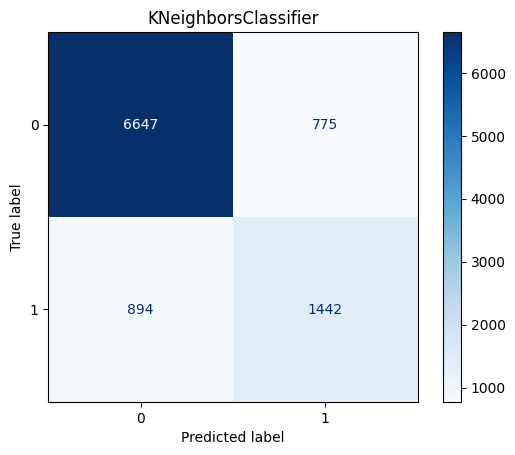

In [119]:
# Display the confusion matrix visually
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)

disp.plot(cmap='Blues')

plt.title(type(knn_base).__name__)

plt.show()

In [120]:
# Print the classification report for the logistic regression base model
print(classification_report(y_test,y_pred_Log_reg))

              precision    recall  f1-score   support

           0       0.88      0.93      0.90      7422
           1       0.72      0.58      0.64      2336

    accuracy                           0.84      9758
   macro avg       0.80      0.76      0.77      9758
weighted avg       0.84      0.84      0.84      9758



###Logistic Regression Cross Validation

### KFold Cross Validation

In [121]:
# Initialize KFold cross-validation with 5 splits and shuffling
kf_obj = KFold(n_splits = 5, shuffle = True)

# Perform cross-validation for  logistic regression
scores = cross_val_score(LogisticRegression(), X, y, cv = kf_obj)
print('Cross validation scores:',scores)
print('Mean of cv scores:', scores.mean())
print('Minimum cv:', scores.min())
print('Maximum cv:', scores.max())
diff = scores.max() - scores.min()
print('Difference b/w min and max cv:', diff)

Cross validation scores: [0.84443534 0.85068662 0.85519574 0.85263374 0.85089158]
Mean of cv scores: 0.8507686001229761
Minimum cv: 0.8444353351096536
Maximum cv: 0.8551957368313179
Difference b/w min and max cv: 0.010760401721664259


###Grid Search Cross Validation

In [ ]:
# Define the parameters for GridSearchCV
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

# Build the GridSearchCV model
grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Train the model
grid.fit(X_train, y_train)

# Display best parameters and score
print("Best parameters are:", grid.best_params_)
print("Best cross validation score is:", grid.best_score_)

# Build the Logistic Regression model using the best parameters
lr_model_HPT = LogisticRegression(
    C=grid.best_params_['C'],
    penalty=grid.best_params_['penalty'],
    solver=grid.best_params_['solver'],
    max_iter=1000,
    random_state=42
)

# Train the model
lr_model_HPT.fit(X_train, y_train)

# Make predictions
y_pred_lr_HPT = lr_model_HPT.predict(X_test)

# Evaluate the model
acc_lr_HPT = accuracy_score(y_test, y_pred_lr_HPT)
pre_lr_HPT = precision_score(y_test, y_pred_lr_HPT)
rec_lr_HPT = recall_score(y_test, y_pred_lr_HPT)
f1_lr_HPT = f1_score(y_test, y_pred_lr_HPT)

print("Accuracy :", acc_lr_HPT)
print("Precision:", pre_lr_HPT)
print("Recall   :", rec_lr_HPT)
print("F1 Score :", f1_lr_HPT)

###Randomized Search Cross Validation

In [122]:
# Define the parameters to check for RandomizedSearchCV
param_grid = {
    'C': np.logspace(-3, 3, 20),      # Regularization strength
    'penalty': ['l1', 'l2'],          # Regularization type
    'solver': ['liblinear'],          # Solver supporting both l1 and l2
    'max_iter': [500, 1000, 1500]
}

# Build the RandomizedSearchCV model object
random_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

# Train the model using RandomizedSearchCV
random_search.fit(X_train, y_train)

# Display the best parameters and score
print("Best parameters are:", random_search.best_params_)
print("Best cross validation score is:", random_search.best_score_)

# Build the model using the best parameters identified
lr_model_HPT = random_search.best_estimator_

# Train the model
lr_model_HPT.fit(X_train, y_train)

# Make predictions
y_pred_lr_HPT = lr_model_HPT.predict(X_test)

# Evaluate the model
acc_lr_HPT = accuracy_score(y_test, y_pred_lr_HPT)

print("Accuracy:", acc_lr_HPT)


print("Accuracy :", accuracy_score(y_test, y_pred_lr_HPT))
print("Precision:", precision_score(y_test, y_pred_lr_HPT))
print("Recall   :", recall_score(y_test, y_pred_lr_HPT))
print("F1 Score :", f1_score(y_test, y_pred_lr_HPT))



Best parameters are: {'solver': 'liblinear', 'penalty': 'l2', 'max_iter': 1500, 'C': np.float64(0.1623776739188721)}
Best cross validation score is: 0.8524798609130384
Accuracy: 0.8435130149620824
Accuracy : 0.8435130149620824
Precision: 0.7127827459231983
Recall   : 0.5800513698630136
F1 Score : 0.6396034930375265


##Hyperparameter Tuning using Randomized Search CV

In [124]:

# Define the parameter distribution for RandomizedSearchCV for Logistic Regression
param_dist = {
    "C": np.logspace(-4,4,30),
    "penalty": ["l1","l2"],
    "solver": ["liblinear"]
}

# Create a RandomizedSearchCV object for Logistic Regression
random_search = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000),
    param_distributions=param_dist,
    n_iter=5,
    cv=skf,
    scoring="accuracy",
    random_state=42,
    n_jobs=-1
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("Best Parameters")
print(random_search.best_params_)

print("Best CV Score")
print(random_search.best_score_)

Best Parameters
{'solver': 'liblinear', 'penalty': 'l1', 'C': np.float64(9.236708571873866)}
Best CV Score
0.8523262839760175


##Evaluate Stacking Ensemble

In [125]:
# Define the base models for stacking
base_models = [

    ('knn', KNeighborsClassifier(n_neighbors=5)),

    ('dt', DecisionTreeClassifier(
        max_depth=10,
        random_state=42
    ))

]

# Define the meta-classifier (final estimator)
meta_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Create the Stacking Classifier
stack_model = StackingClassifier(

    estimators=base_models,

    final_estimator=meta_model,

    cv=5,

    n_jobs=-1

)

# Train the stacking model
stack_model.fit(X_train, y_train)
# Make predictions using the stacking model
y_pred_stack = stack_model.predict(X_test)

# Calculate evaluation metrics for the stacking model
accuracy = accuracy_score(y_test, y_pred_stack)
precision = precision_score(y_test, y_pred_stack)
recall = recall_score(y_test, y_pred_stack)
f1 = f1_score(y_test, y_pred_stack)

print("="*50)
print("STACKING CLASSIFIER (KNN + Decision Tree)")
print("="*50)

print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_stack))

STACKING CLASSIFIER (KNN + Decision Tree)
Accuracy : 0.8515
Precision: 0.7388
Recall   : 0.5873
F1 Score : 0.6544

Classification Report

              precision    recall  f1-score   support

           0       0.88      0.93      0.91      7422
           1       0.74      0.59      0.65      2336

    accuracy                           0.85      9758
   macro avg       0.81      0.76      0.78      9758
weighted avg       0.84      0.85      0.85      9758



### Tojo

## SVM

In [126]:
# build model object
svm_obj = SVC()

# train model
svm_obj.fit(X_train, y_train)

# make predictions using the model
y_pred_svm = svm_obj.predict(X_test)

# evaluate model performance
svm_accuracy = accuracy_score(y_test, y_pred_svm)

In [127]:
# model accuracy

print("SVM Accuracy : ", svm_accuracy)

SVM Accuracy :  0.8486370157819225


In [128]:
cm = confusion_matrix(y_test,y_pred_svm)
print(cm)
print(classification_report(y_test,y_pred_svm))

[[6976  446]
 [1031 1305]]
              precision    recall  f1-score   support

           0       0.87      0.94      0.90      7422
           1       0.75      0.56      0.64      2336

    accuracy                           0.85      9758
   macro avg       0.81      0.75      0.77      9758
weighted avg       0.84      0.85      0.84      9758



###  SVM K-fold Cross Validation

In [129]:
kf_obj = KFold(n_splits = 5, shuffle = True)

scores = cross_val_score(SVC(), X, y, cv = kf_obj)
print('Cross validation scores:',scores)
# print('Mean of cv scores:', np.mean(scores))
print('Mean of cv scores:', scores.mean())
print('Minimum cv:', scores.min())
print('Maximum cv:', scores.max())
diff = scores.max() - scores.min()
print('Difference b/w min and max cv:', diff)

Cross validation scores: [0.8564255  0.84750974 0.85355606 0.85458086 0.85140398]
Mean of cv scores: 0.8526952244312358
Minimum cv: 0.8475097356015577
Maximum cv: 0.8564254970280796
Difference b/w min and max cv: 0.00891576142652184


### SVM grid search cross validation



In [151]:
# Define the parameters to search
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Build the Grid Search object
grid = GridSearchCV(
    estimator=SVC(),
    param_grid=param_grid,
    cv=2,
    scoring='accuracy'
)

# Train the model
grid.fit(X_train, y_train)

# Display the best parameters and score
print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# Build the model using the best parameters
svm_model_HPT = grid.best_estimator_

# Make predictions
y_pred_svm_HPT = svm_model_HPT.predict(X_test)

# Evaluate the model
acc_svm_HPT = accuracy_score(y_test, y_pred_svm_HPT)

print("Accuracy:", acc_svm_HPT)

KeyboardInterrupt: 

### SVM Random search cross validation

In [130]:

# Define the parameters to check
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

# Build the model object
random_search = RandomizedSearchCV(
    estimator=SVC(),
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

# Display the best parameters and score
print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

# Build the model using the best parameters
svm_model_HPT = random_search.best_estimator_

# Make predictions using the model
y_pred_svm_HPT = svm_model_HPT.predict(X_test)

# Evaluate the model performance
acc_svm_HPT = accuracy_score(y_test, y_pred_svm_HPT)

print("Accuracy:", acc_svm_HPT)

KeyboardInterrupt: 

## Naive Bayes

In [131]:
# build model object
nb_model = GaussianNB()

# Train the model
nb_model.fit(X_train, y_train)

# make predictions using the model
y_pred_nb = nb_model.predict(X_test)

# evaluate model performance
nb_accuracy = accuracy_score(y_test, y_pred_nb)

In [132]:
# accuracy of the model
print("Naive Bayes : ", nb_accuracy)

Naive Bayes :  0.7554826808772289


In [133]:
cm = confusion_matrix(y_test,y_pred_nb)
print(cm)
print(classification_report(y_test,y_pred_nb))

[[5383 2039]
 [ 347 1989]]
              precision    recall  f1-score   support

           0       0.94      0.73      0.82      7422
           1       0.49      0.85      0.63      2336

    accuracy                           0.76      9758
   macro avg       0.72      0.79      0.72      9758
weighted avg       0.83      0.76      0.77      9758



###  Naive Bayes K-fold Cross Validation

In [134]:
# K-Fold
kf_obj = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross Validation
scores = cross_val_score(GaussianNB(), X, y, cv=kf_obj)

print("Cross validation scores:", scores)
print("Mean of CV scores:", scores.mean())
print("Minimum CV:", scores.min())
print("Maximum CV:", scores.max())
print("Difference between Min and Max CV:", scores.max() - scores.min())

Cross validation scores: [0.76480836 0.75804468 0.7579422  0.76091412 0.76275876]
Mean of CV scores: 0.76089362574298
Minimum CV: 0.7579422012707522
Maximum CV: 0.764808362369338
Difference between Min and Max CV: 0.0068661610985858434


###  Naive Bayes grid search cross validation

In [135]:
# Define the parameters
param_grid = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

# Build the Grid Search object
grid = GridSearchCV(
    GaussianNB(),
    param_grid=param_grid,
    cv=2,
    scoring='accuracy'
)

# Train the model
grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Cross Validation Score:", grid.best_score_)

# Build the model using the best parameters
nb_model_HPT = grid.best_estimator_

# Make predictions
y_pred_nb_HPT = nb_model_HPT.predict(X_test)

# Evaluate the model
acc_nb_HPT = accuracy_score(y_test, y_pred_nb_HPT)

print("Accuracy:", acc_nb_HPT)

Best Parameters: {'var_smoothing': 1e-08}
Best Cross Validation Score: 0.7432619389219102
Accuracy: 0.7554826808772289


###  Naive Bayes Random search cross validation

In [136]:
# Define the parameters
param_dist = {
    'var_smoothing': [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

# Build the Random Search object
random_search = RandomizedSearchCV(
    GaussianNB(),
    param_distributions=param_dist,
    n_iter=5,
    cv=5,
    scoring='accuracy',
    random_state=42
)

# Train the model
random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best Cross Validation Score:", random_search.best_score_)

# Build the model using the best parameters
nb_model_HPT = random_search.best_estimator_

# Make predictions
y_pred_nb_HPT = nb_model_HPT.predict(X_test)

# Evaluate the model
acc_nb_HPT = accuracy_score(y_test, y_pred_nb_HPT)

print("Accuracy:", acc_nb_HPT)

Best Parameters: {'var_smoothing': 1e-12}
Best Cross Validation Score: 0.7627332119906189
Accuracy: 0.7554826808772289


## Ensemble Models

### ADA Boost

In [137]:
# Build model object
ada_model = AdaBoostClassifier(random_state=42)

# Train the model
ada_model.fit(X_train, y_train)

# Make predictions
y_pred_ada = ada_model.predict(X_test)

# Evaluate model performance
ada_accuracy = accuracy_score(y_test, y_pred_ada)

print("Accuracy:", ada_accuracy)

Accuracy: 0.8501742160278746


### Bagging

In [138]:
# build model object
bagging_model = BaggingClassifier(
                                  estimator = DecisionTreeClassifier(),
                                  n_estimators = 8,
                                  max_samples = 0.6
                                  )

# train model
bagging_model.fit(X_train, y_train)

# make predictions using the model
y_pred_bag = bagging_model.predict(X_test)

# evaluate model performance
acc_bag = accuracy_score(y_test, y_pred_bag)

# Deep Learning

# Build the Artificial Neural Network Model

In [139]:
input_dim = X_train.shape[1]

# Build model
ann_model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu', input_shape=(input_dim,)),
    Dropout(0.3),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(16, activation='relu'),

    Dense(1, activation='sigmoid')   # Binary classification
])

##Compile Model

In [140]:
ann_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model summary
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,233 (59.50 KB)

 Trainable params: 15,233 (59.50 KB)

 Non-trainable params: 0 (0.00 B)

##Train the Model

In [142]:
# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = ann_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8533 - loss: 0.3215 - val_accuracy: 0.8535 - val_loss: 0.3182
Epoch 2/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8533 - loss: 0.3163 - val_accuracy: 0.8583 - val_loss: 0.3138
Epoch 3/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8549 - loss: 0.3140 - val_accuracy: 0.8582 - val_loss: 0.3168
Epoch 4/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8551 - loss: 0.3134 - val_accuracy: 0.8587 - val_loss: 0.3123
Epoch 5/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8572 - loss: 0.3106 - val_accuracy: 0.8582 - val_loss: 0.3152
Epoch 6/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8561 - loss: 0.3081 - val_accuracy: 0.8586 - val_loss: 0.3109
Epoch 7/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8575 - loss: 0.3061 - val_accuracy: 0.8524 - val_loss: 0.3164
Epoch 8/50
976/976 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8581 - loss: 0.3060 - val_accuracy: 0.

##Hyperparameter Tuning

In [145]:


# Parameter Grid
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5],
    'max_features': [None, 'sqrt', 'log2']
}

# Grid Search
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Training... Please wait")

grid_search.fit(X_train, y_train)

print("\nBest Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_,4))

Training... Please wait
Fitting 5 folds for each of 270 candidates, totalling 1350 fits

Best Parameters:
{'criterion': 'entropy', 'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best Cross Validation Score:
0.8586


##Train the best model

In [146]:
# Best model obtained from GridSearchCV
best_dt_model = grid_search.best_estimator_

# Train the model
best_dt_model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=2,
                       random_state=42)

##Evaluate the Model

In [152]:
y_pred_best = best_dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("Decision Tree (Tuned) Results")
print("--------------------------------")
print("Accuracy :", round(accuracy,4))
print("Precision:", round(precision,4))
print("Recall   :", round(recall,4))
print("F1 Score :", round(f1,4))

Decision Tree (Tuned) Results
--------------------------------
Accuracy : 0.8516
Precision: 0.7408
Recall   : 0.5848
F1 Score : 0.6536


##Make Predictions

In [153]:
# Predict Probabilities on Test Data
y_pred_prob = ann_model.predict(X_test)

305/305 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [154]:
# Convert Probabilities to Binary Predictions
y_pred_ann = (y_pred_prob > 0.5).astype(int)

In [155]:
print(f"Total predictions made : {len(y_pred_ann)}")
print(f"\nFirst 10 probabilities : {y_pred_prob[:10].flatten().round(4)}")
print(f"First 10 predictions   : {y_pred_ann[:10].flatten()}")
print(f"First 10 actual values : {y_test.values[:10]}")

Total predictions made : 9758

First 10 probabilities : [1.300e-02 2.836e-01 4.400e-01 1.061e-01 4.328e-01 8.600e-02 9.200e-03
 2.000e-04 4.080e-02 1.131e-01]
First 10 predictions   : [0 0 0 0 0 0 0 0 0 0]
First 10 actual values : [0 0 0 0 1 0 0 0 0 0]


In [156]:
unique, counts = np.unique(y_pred_ann, return_counts=True)
print(f"Class 0 (<=50K): {counts[0]} predictions")
print(f"Class 1 (>50K) : {counts[1]} predictions")

Class 0 (<=50K): 7791 predictions
Class 1 (>50K) : 1967 predictions


##Confusion matrix

In [157]:
cm_ann = confusion_matrix(y_test, y_pred_ann)

In [158]:
# Display Raw Confusion Matrix
print(f"\n{cm_ann}")


[[6892  530]
 [ 899 1437]]


In [159]:
# Extract Individual Values
tn, fp, fn, tp = cm_ann.ravel()
print(f"\nTrue Negatives  (TN): {tn}  → Correctly predicted <=50K")
print(f"False Positives (FP): {fp}   → Wrongly predicted >50K")
print(f"False Negatives (FN): {fn}   → Wrongly predicted <=50K")
print(f"True Positives  (TP): {tp}   → Correctly predicted >50K")


True Negatives  (TN): 6892  → Correctly predicted <=50K
False Positives (FP): 530   → Wrongly predicted >50K
False Negatives (FN): 899   → Wrongly predicted <=50K
True Positives  (TP): 1437   → Correctly predicted >50K


##Classification Matrix

In [160]:
# Calculate Overall Metrics
ann_accuracy  = accuracy_score(y_test, y_pred_ann)
ann_precision = precision_score(y_test, y_pred_ann)
ann_recall    = recall_score(y_test, y_pred_ann)
ann_f1        = f1_score(y_test, y_pred_ann)
ann_roc_auc   = roc_auc_score(y_test, y_pred_prob)

In [161]:
# Display Summary Metrics
print(f"Accuracy  : {ann_accuracy:.4f}  ({ann_accuracy*100:.2f}%)")
print(f"Precision : {ann_precision:.4f}  ({ann_precision*100:.2f}%)")
print(f"Recall    : {ann_recall:.4f}  ({ann_recall*100:.2f}%)")
print(f"F1 Score  : {ann_f1:.4f}  ({ann_f1*100:.2f}%)")
print(f"ROC AUC   : {ann_roc_auc:.4f}  ({ann_roc_auc*100:.2f}%)")

Accuracy  : 0.8536  (85.36%)
Precision : 0.7306  (73.06%)
Recall    : 0.6152  (61.52%)
F1 Score  : 0.6679  (66.79%)
ROC AUC   : 0.9086  (90.86%)


In [162]:
# Display Full Classification Report
print(classification_report(
    y_test,
    y_pred_ann,
    target_names=['<=50K', '>50K']
))

              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7422
        >50K       0.73      0.62      0.67      2336

    accuracy                           0.85      9758
   macro avg       0.81      0.77      0.79      9758
weighted avg       0.85      0.85      0.85      9758



##Plot training history

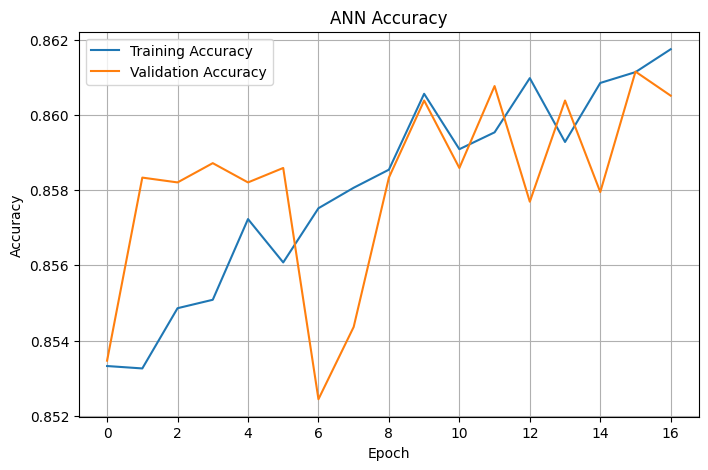

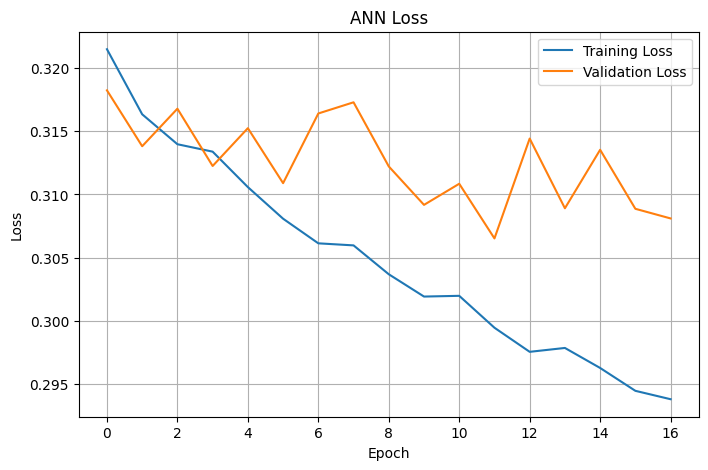

In [163]:
# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('ANN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('ANN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

##Prevent Overfitting

In [164]:
print("Training completed using Early Stopping.")

print(f"Best Validation Accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Lowest Validation Loss   : {min(history.history['val_loss']):.4f}")

print("\nOverfitting Prevention Techniques Used:")
print("✓ EarlyStopping")
print("✓ Validation Split")
print("✓ Restore Best Weights")
print("✓ Adam Optimizer")

Training completed using Early Stopping.
Best Validation Accuracy : 0.8612
Lowest Validation Loss   : 0.3065

Overfitting Prevention Techniques Used:
✓ EarlyStopping
✓ Validation Split
✓ Restore Best Weights
✓ Adam Optimizer


##Save the trained model

In [165]:
# Save ANN Model

ann_model.save("Adult_Income_ANN_Model.keras")

print("Model saved successfully as Adult_Income_ANN_Model.keras")

Model saved successfully as Adult_Income_ANN_Model.keras


In [167]:
# Comparision of all accuracy
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "SVM",
        "Naive Bayes",
        "ANN"
    ],
    "Accuracy": [
        acc_log_reg,
        acc_DT,
        np.nan,
        svm_accuracy,
        nb_accuracy,
        ann_accuracy
    ]
})

comparison.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
5,ANN,0.853556
3,SVM,0.848637
0,Logistic Regression,0.844948
1,Decision Tree,0.816868
4,Naive Bayes,0.755483
2,Random Forest,NaN
